<a href="https://colab.research.google.com/github/EgorKaduba/ForecastRus/blob/ml-predict/ml/predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Предразминка


In [ ]:
!pip install catboost
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from tqdm import tqdm
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error, mean_absolute_error

In [ ]:
df = pd.read_csv('/content/Full_df.csv')
df = df.sort_values(['oktmo', 'year'])

In [ ]:
df.rename({'death': 'deaths'}, axis = 1, inplace=True)

In [ ]:
df.drop('salary', axis = 1, inplace = True)

In [ ]:
for col in ['births', 'deaths', 'migration', 'Target']:
    df[col] = df.groupby('oktmo')[col].transform(lambda x: x.interpolate())

#Метрики


In [ ]:
train_df = df[df['year'] < 2020].copy()
test_df = df[(df['year'] >= 2020) & (df['oktmo']!=42630000)].copy()


LAGS = [1, 2, 3]
features = []

for col in ['births', 'deaths', 'migration']:
    for lag in LAGS:
        train_df[f'{col}_lag{lag}'] = train_df.groupby('oktmo')[col].shift(lag)
        features.append(f'{col}_lag{lag}')

train_df['year_norm'] = train_df['year'] - train_df['year'].min()
features.append('year_norm')

cat_features = ['region'] if 'region' in train_df.columns else []

train_model = train_df.dropna().copy()


targets = ['births', 'deaths', 'migration']
models = {}

for target in targets:
    print(f'Training {target} on data up to 2019...')
    model = CatBoostRegressor(
        iterations=400,
        depth=6,
        learning_rate=0.05,
        verbose=100,
        random_seed=42
    )
    model.fit(
        train_model[features + cat_features],
        train_model[target],
        cat_features=cat_features
    )
    models[target] = model


def forecast(train_history, models, horizon=5):

    df_future = train_history.copy()
    last_year = df_future['year'].max()

    for step in tqdm(range(1, horizon + 1)):
        year = last_year + step


        df_step = df_future.groupby('oktmo').tail(1).copy()
        df_step['year'] = year
        df_step['year_norm'] = year - train_history['year'].min()

        for col in ['births', 'deaths', 'migration']:
            hist = df_future.groupby('oktmo')[col]
            df_step[f'{col}_lag1'] = hist.tail(1).values
            df_step[f'{col}_lag2'] = hist.tail(2).groupby(df_future['oktmo']).head(1).values
            df_step[f'{col}_lag3'] = hist.tail(3).groupby(df_future['oktmo']).head(1).values


        for target in targets:
            pred = models[target].predict(df_step[features + cat_features])
            prev = df_step[f'{target}_lag1']
            pred = np.clip(pred, prev * 0.97, prev * 1.03)
            df_step[target] = pred


        prev_pop = df_step['Target']
        df_step['Target'] = prev_pop + df_step['births'] - df_step['deaths'] + df_step['migration']
        df_step['Target'] = np.clip(df_step['Target'], prev_pop * 0.97, prev_pop * 1.03)

        df_future = pd.concat([df_future, df_step], ignore_index=True)


    return df_future[df_future['year'] > last_year]

forecast_df = forecast(train_model, models, horizon=5)


comparison = forecast_df[['oktmo', 'year', 'Target']].merge(
    test_df[['oktmo', 'year', 'Target']],
    on=['oktmo', 'year'],
    suffixes=('_pred', '_true')
)

comparison['ape'] = 100 * np.abs(comparison['Target_pred'] - comparison['Target_true']) / np.abs(comparison['Target_true'])


mape_total = comparison['ape'].mean()
print(f'MAPE {mape_total:.2f}%')
print(f'MAE {mean_absolute_error(comparison['Target_true'], comparison['Target_pred'])}')
print(f'RMSE {mean_squared_error(comparison['Target_true'], comparison['Target_pred'])**0.5}')



Training births on data up to 2019...
0:	learn: 2050.8931186	total: 7.21ms	remaining: 2.88s
100:	learn: 562.7101691	total: 673ms	remaining: 1.99s
200:	learn: 533.0578716	total: 1.5s	remaining: 1.48s
300:	learn: 524.1814307	total: 1.87s	remaining: 614ms
399:	learn: 521.0472074	total: 2.12s	remaining: 0us
Training deaths on data up to 2019...
0:	learn: 1898.6870719	total: 2.72ms	remaining: 1.08s
100:	learn: 490.8316060	total: 260ms	remaining: 770ms
200:	learn: 465.7474252	total: 509ms	remaining: 504ms
300:	learn: 458.7636795	total: 748ms	remaining: 246ms
399:	learn: 456.0570360	total: 988ms	remaining: 0us
Training migration on data up to 2019...
0:	learn: 1587.1338563	total: 3.32ms	remaining: 1.33s
100:	learn: 713.1508892	total: 265ms	remaining: 785ms
200:	learn: 644.3807002	total: 508ms	remaining: 503ms
300:	learn: 607.7151017	total: 752ms	remaining: 247ms
399:	learn: 585.1206744	total: 998ms	remaining: 0us


100%|██████████| 5/5 [00:00<00:00, 30.67it/s]

MAPE 2.96%
MAE 1606.1024463536407
RMSE 7097.1554905390185


#Предикт


In [ ]:
LAGS = [1, 2, 3, 4, 5]
features = []

for col in ['births', 'deaths', 'migration']:
    for lag in LAGS:
        df[f'{col}_lag{lag}'] = df.groupby('oktmo')[col].shift(lag)
        features.append(f'{col}_lag{lag}')

df['year_norm'] = df['year'] - df['year'].min()
features.append('year_norm')

cat_features = ['region'] if 'region' in df.columns else []


df_model = df.dropna().copy()


models = {}
targets = ['births', 'deaths', 'migration']

for target in targets:
    print(f'Training {target}')
    model = CatBoostRegressor(
        iterations=600,
        depth=8,
        learning_rate=0.01,
        verbose=100
    )

    model.fit(
        df_model[features + cat_features],
        df_model[target],
        cat_features=cat_features
    )

    models[target] = model


def forecast(df, models, horizon=12):
    df_future = df.copy()
    last_year = df_future['year'].max()

    for step in tqdm(range(1, horizon + 1)):
        year = last_year + step

        df_step = df_future.groupby('oktmo').tail(1).copy()
        df_step['year'] = year
        df_step['year_norm'] = year - df_future['year'].min()


        for col in ['births', 'deaths', 'migration']:
            hist = df_future.groupby('oktmo')[col]

            df_step[f'{col}_lag1'] = hist.tail(1).values
            df_step[f'{col}_lag2'] = hist.tail(2).groupby(df_future['oktmo']).head(1).values
            df_step[f'{col}_lag3'] = hist.tail(3).groupby(df_future['oktmo']).head(1).values

        for target in ['births', 'deaths', 'migration']:
            pred = models[target].predict(df_step[features + cat_features])
            prev = df_step[f'{target}_lag1']


            pred = np.clip(pred, prev * 0.97, prev * 1.03)
            df_step[target] = pred


        prev_pop = df_step['Target']

        df_step['Target'] = (
            prev_pop
            + df_step['births']
            - df_step['deaths']
            + df_step['migration']
        )

        df_step['Target'] = np.clip(df_step['Target'], prev_pop * 0.97, prev_pop * 1.03)

        df_future = pd.concat([df_future, df_step], ignore_index=True)

    return df_future

forecast_df = forecast(df_model, models, horizon=15)
forecast_df[['year','Target','deaths','births','migration']] = forecast_df[['year','Target','deaths','births','migration']].astype('int64')
forecast_df[['region_name',	'municipality',	'oktmo',	'mun_type',	'year',	'Target',	'deaths',	'births',	'migration']].to_csv('forecast_2035.csv', index=False)


Training births
0:	learn: 1958.0235029	total: 13.4ms	remaining: 8.02s
100:	learn: 1035.6489238	total: 1.06s	remaining: 5.22s
200:	learn: 696.1872133	total: 2.11s	remaining: 4.18s
300:	learn: 565.8048982	total: 3.74s	remaining: 3.71s
400:	learn: 507.9527495	total: 4.91s	remaining: 2.44s
500:	learn: 479.6455602	total: 5.99s	remaining: 1.18s
599:	learn: 464.8033117	total: 7.03s	remaining: 0us
Training deaths
0:	learn: 2160.0635123	total: 11.3ms	remaining: 6.79s
100:	learn: 1171.7958769	total: 1.08s	remaining: 5.33s
200:	learn: 775.2667618	total: 2.12s	remaining: 4.21s
300:	learn: 601.8511969	total: 3.17s	remaining: 3.15s
400:	learn: 512.6362009	total: 4.2s	remaining: 2.08s
500:	learn: 464.1867227	total: 5.24s	remaining: 1.03s
599:	learn: 437.2219225	total: 6.27s	remaining: 0us
Training migration
0:	learn: 1474.0876711	total: 10.8ms	remaining: 6.48s
100:	learn: 996.4104069	total: 1.5s	remaining: 7.4s
200:	learn: 814.5680981	total: 2.73s	remaining: 5.43s
300:	learn: 728.4604835	total: 3.76s

100%|██████████| 15/15 [00:00<00:00, 24.25it/s]


In [ ]:
df2 = pd.read_csv('/content/forecast_2035.csv')
df2[df2['oktmo']==97653000]

,Unnamed: 0,region_name,municipality,oktmo,mun_type,year,Target,deaths,births,migration,...,deaths_lag2,deaths_lag3,deaths_lag4,deaths_lag5,migration_lag1,migration_lag2,migration_lag3,migration_lag4,migration_lag5,year_norm
14715,34097,Чувашская Республика,Ядринский муниципальный район,97653000,Муниципальный район,2015,27489,493,297,-378,...,561.000000,540.000000,547.0,577.0,-425.000000,-517.000000,-369.000000,-386.0,-345.0,9
14716,34098,Чувашская Республика,Ядринский муниципальный район,97653000,Муниципальный район,2016,26065,535,302,-617,...,540.000000,561.000000,540.0,547.0,-378.000000,-425.000000,-517.000000,-369.0,-386.0,10
14717,34099,Чувашская Республика,Ядринский муниципальный район,97653000,Муниципальный район,2017,26065,495,248,-386,...,493.000000,540.000000,561.0,540.0,-617.000000,-378.000000,-425.000000,-517.0,-369.0,11
14718,34100,Чувашская Республика,Ядринский муниципальный район,97653000,Муниципальный район,2018,25432,531,263,-492,...,535.000000,493.000000,540.0,561.0,-386.000000,-617.000000,-378.000000,-425.0,-517.0,12
14719,34101,Чувашская Республика,Ядринский муниципальный район,97653000,Муниципальный район,2019,24672,482,224,-308,...,495.000000,535.000000,493.0,540.0,-492.000000,-386.000000,-617.000000,-378.0,-425.0,13
14720,34102,Чувашская Республика,Ядринский муниципальный район,97653000,Муниципальный район,2020,24106,558,212,-170,...,531.000000,495.000000,535.0,493.0,-308.000000,-492.000000,-386.000000,-617.0,-378.0,14
14721,34103,Чувашская Республика,Ядринский муниципальный район,97653000,Муниципальный район,2021,23589,559,205,-324,...,482.000000,531.000000,495.0,535.0,-170.000000,-308.000000,-492.000000,-386.0,-617.0,15
14722,34104,Чувашская Республика,Ядринский муниципальный район,97653000,Муниципальный район,2022,22911,447,156,-193,...,558.000000,482.000000,531.0,495.0,-324.000000,-170.000000,-308.000000,-492.0,-386.0,16
17113,34104,Чувашская Республика,Ядринский муниципальный район,97653000,Муниципальный район,2023,22439,433,160,-198,...,559.000000,558.000000,531.0,495.0,-193.000000,-324.000000,-170.000000,-492.0,-386.0,10
19246,34104,Чувашская Республика,Ядринский муниципальный район,97653000,Муниципальный район,2024,21979,420,165,-204,...,447.000000,559.000000,531.0,495.0,-198.790000,-193.000000,-324.000000,-492.0,-386.0,11


#Графики

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pred_cols = ['Target',	'deaths','births','migration']

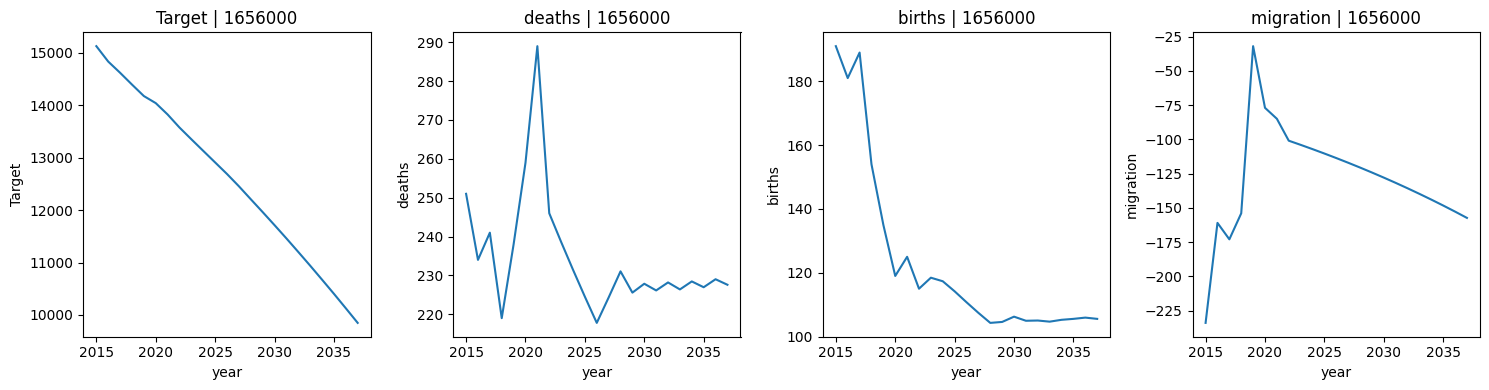

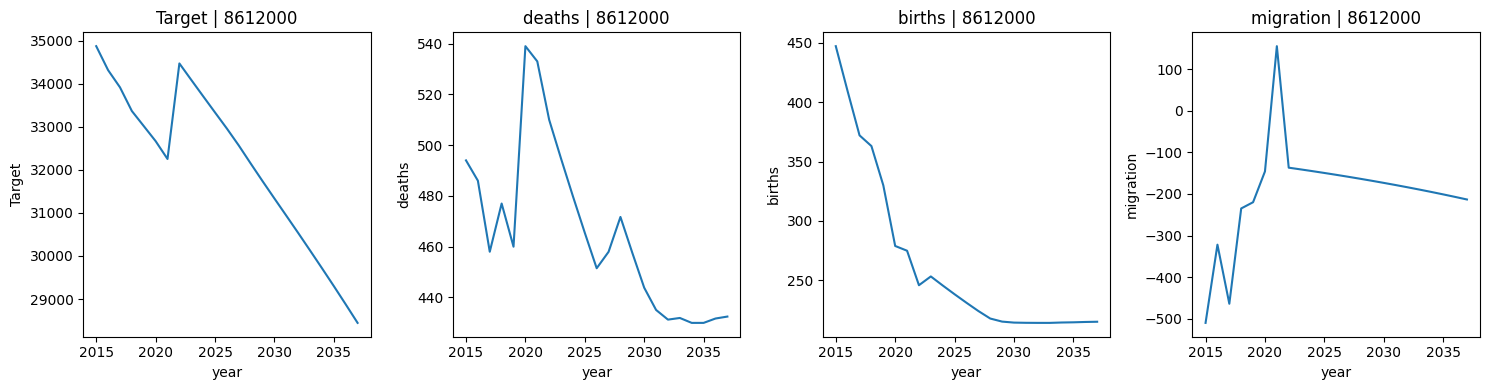

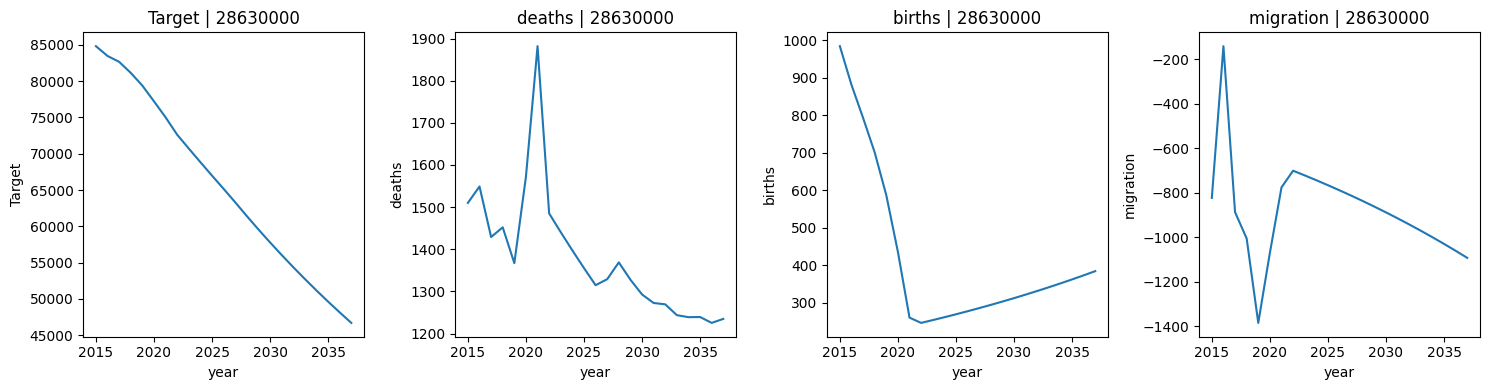

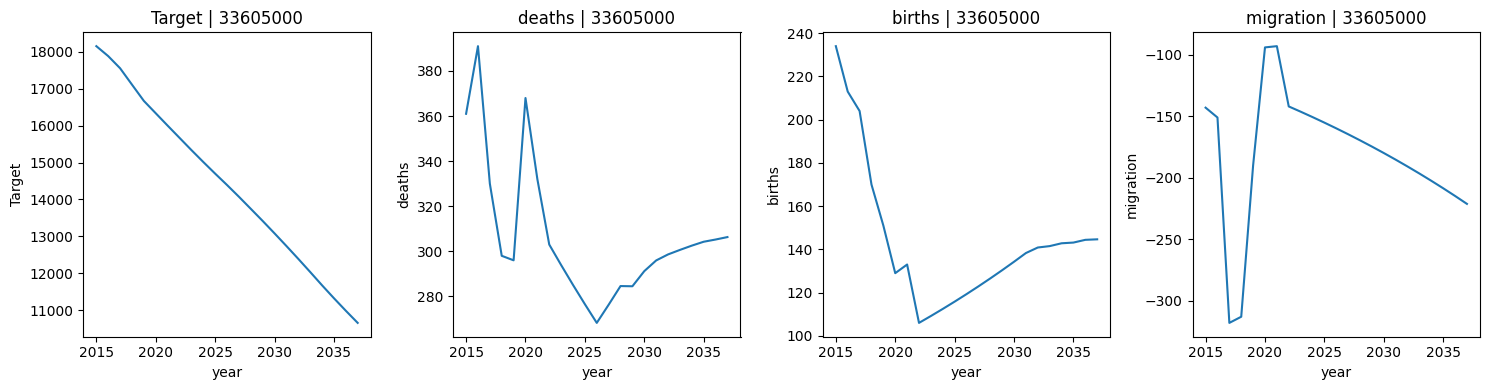

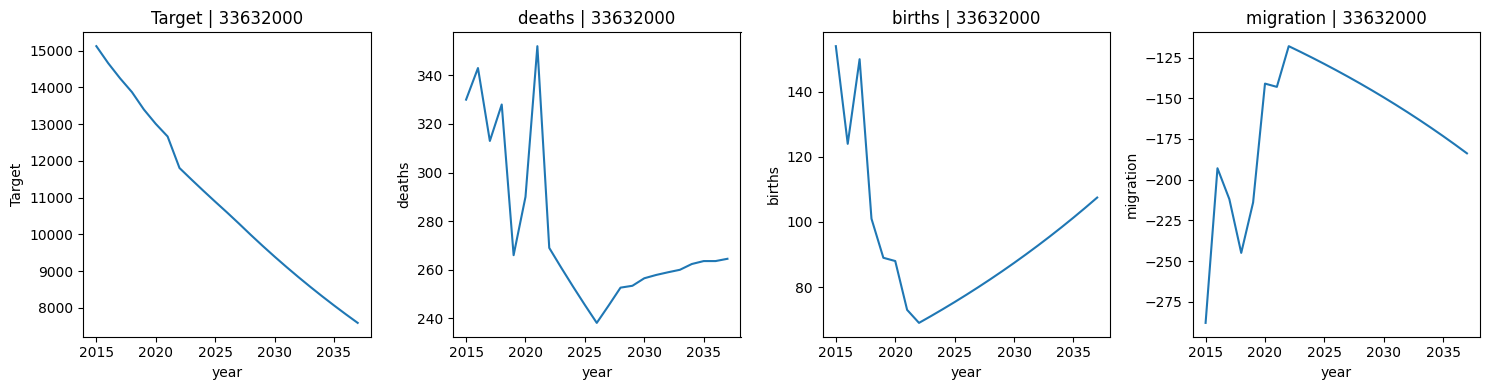

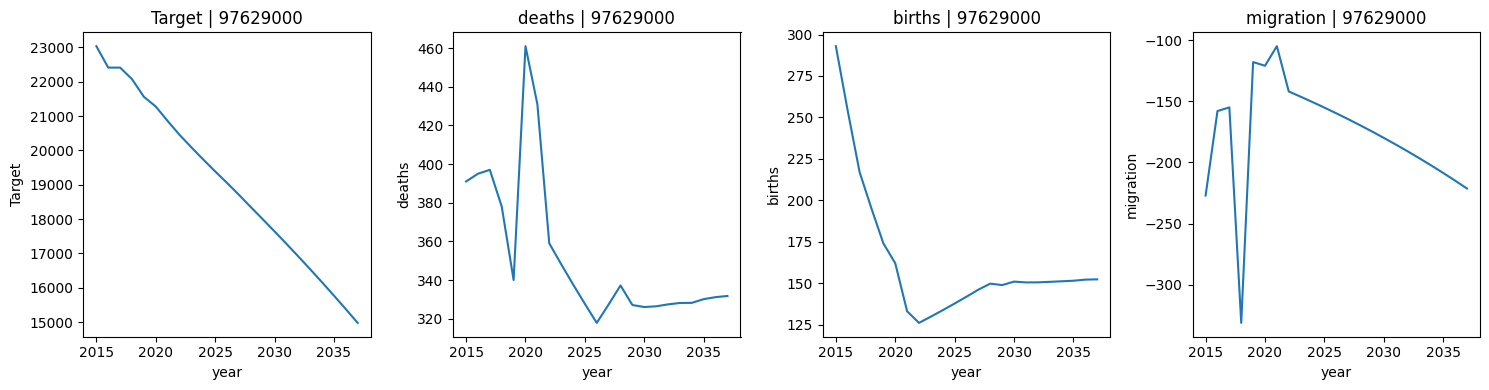

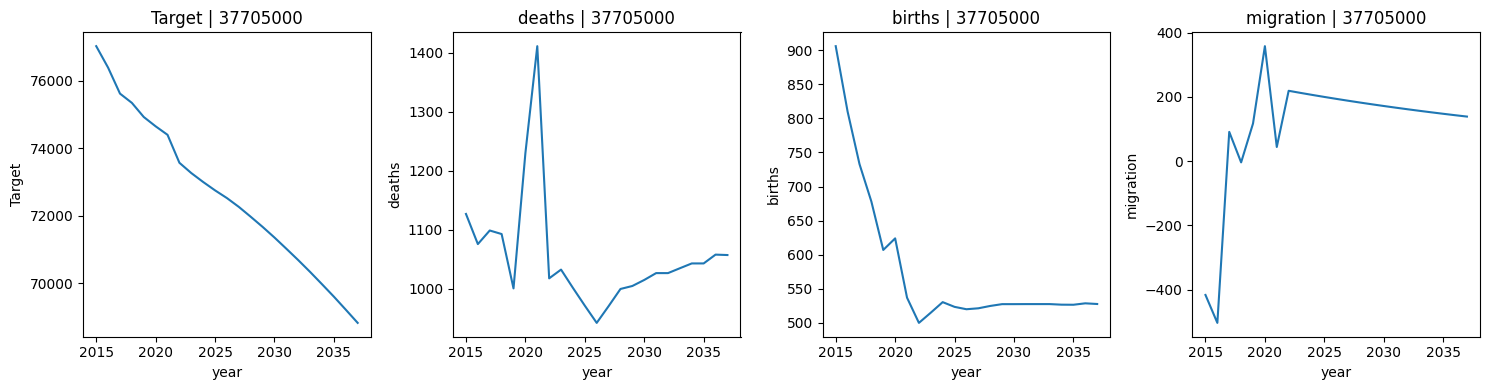

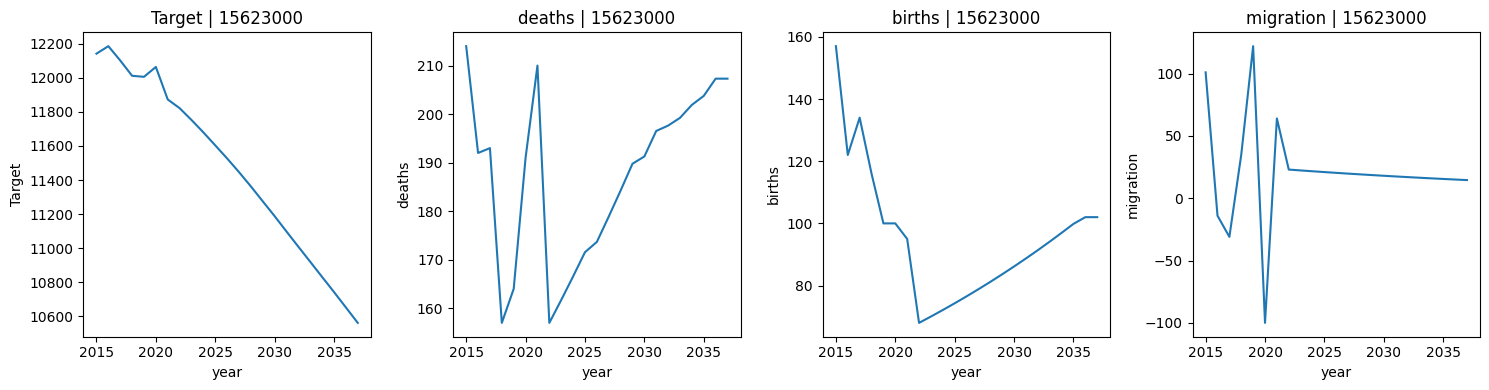

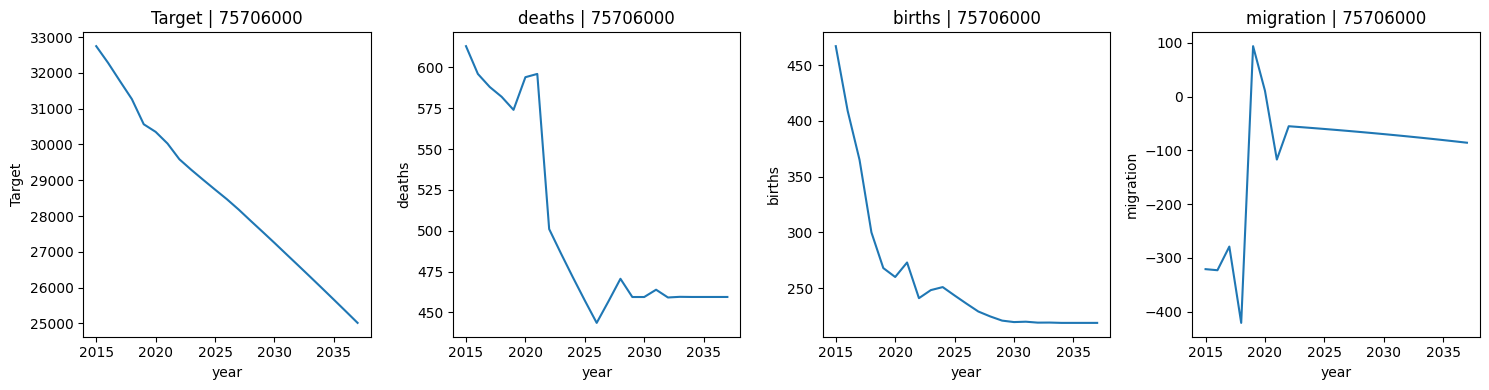

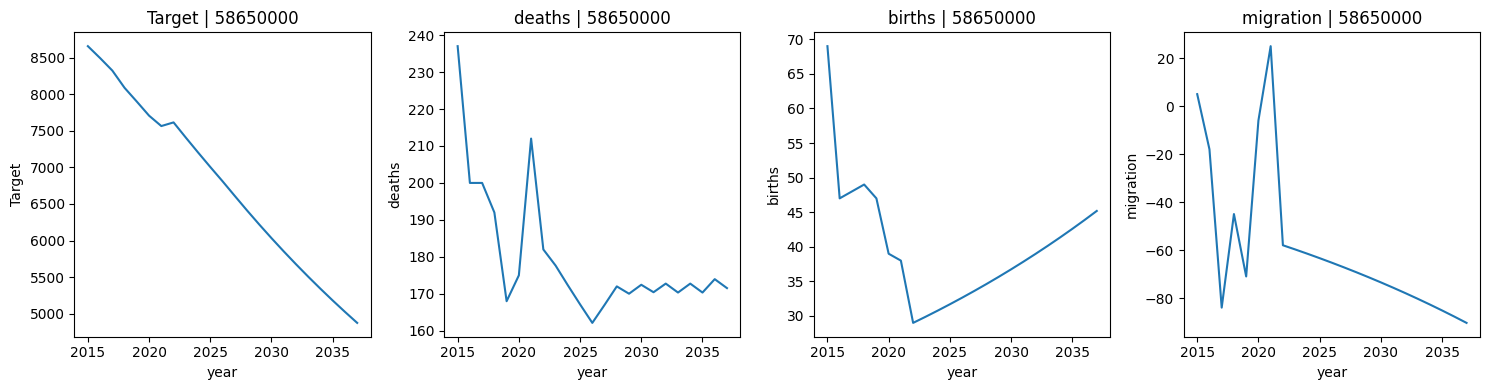

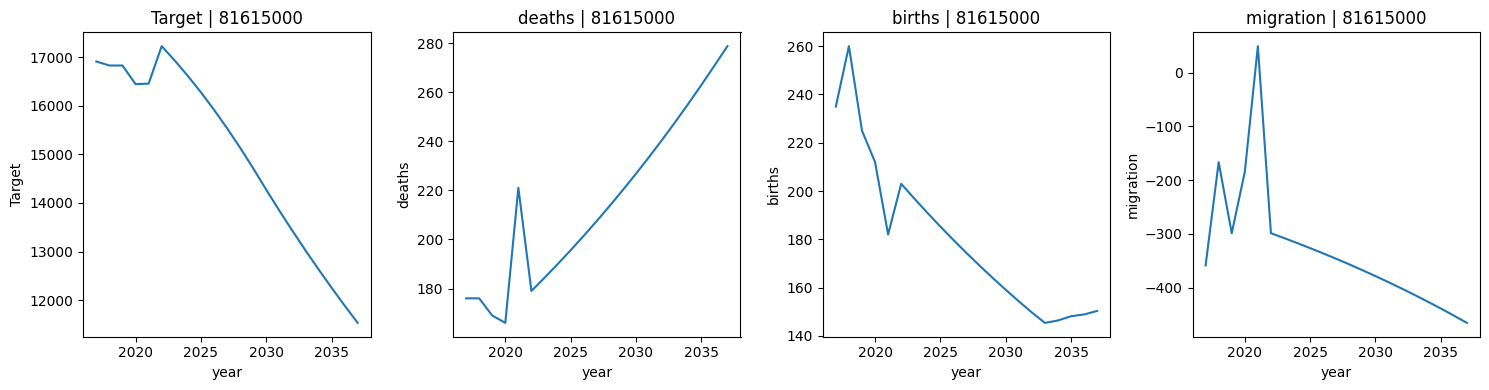

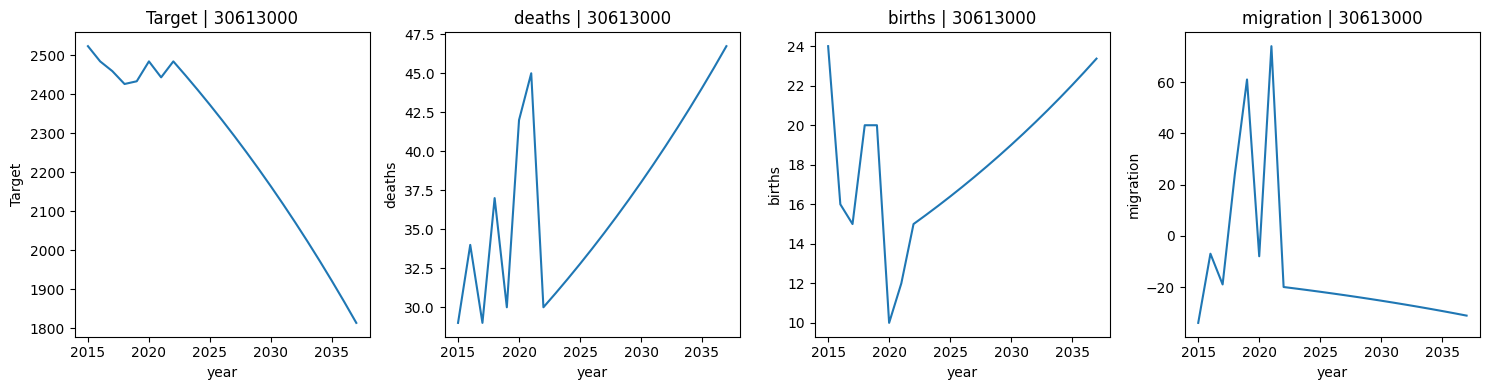

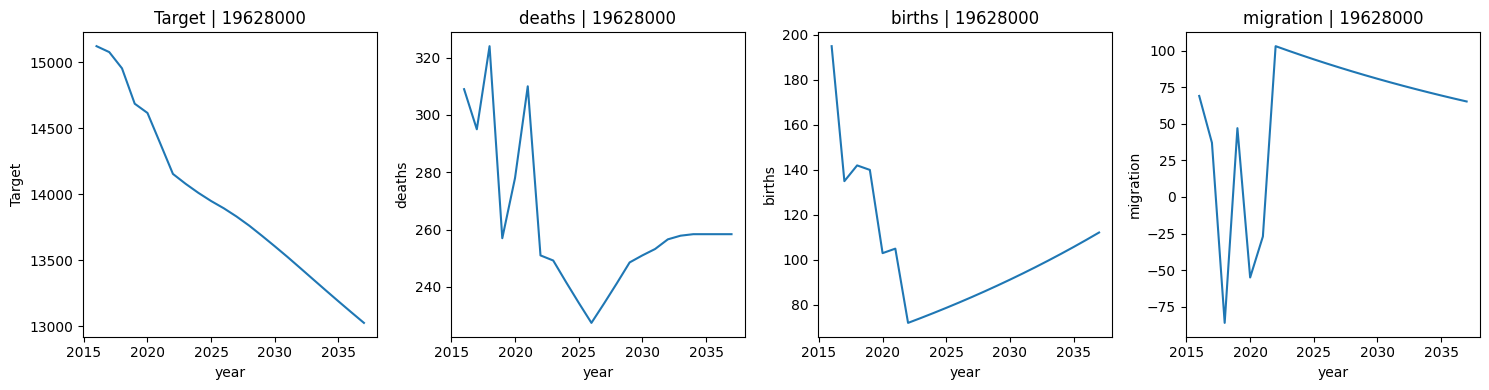

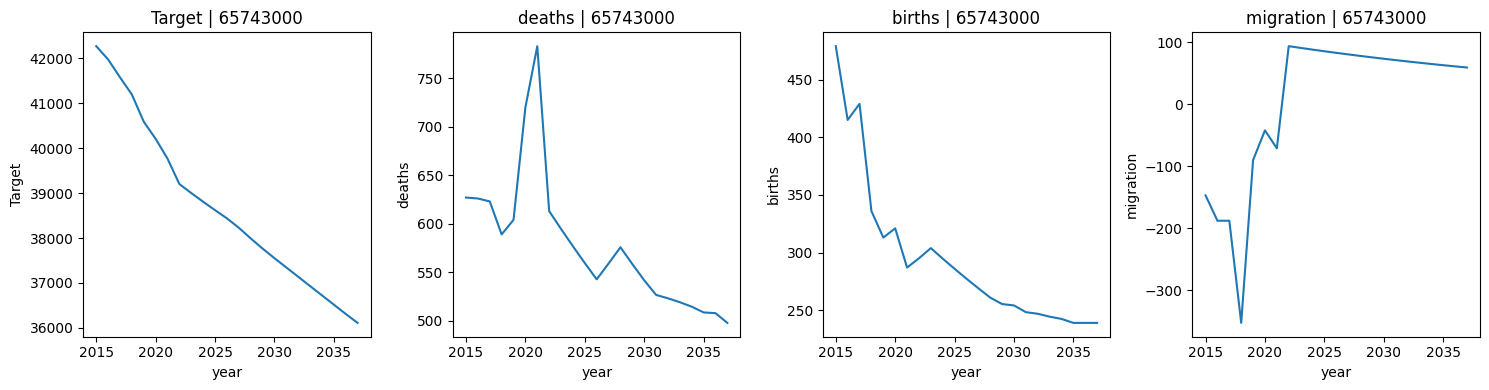

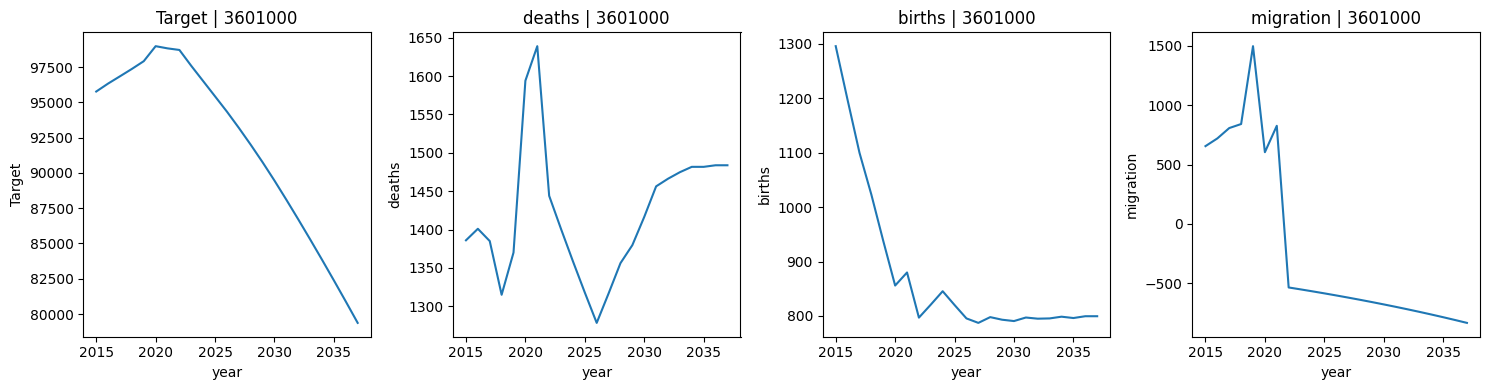

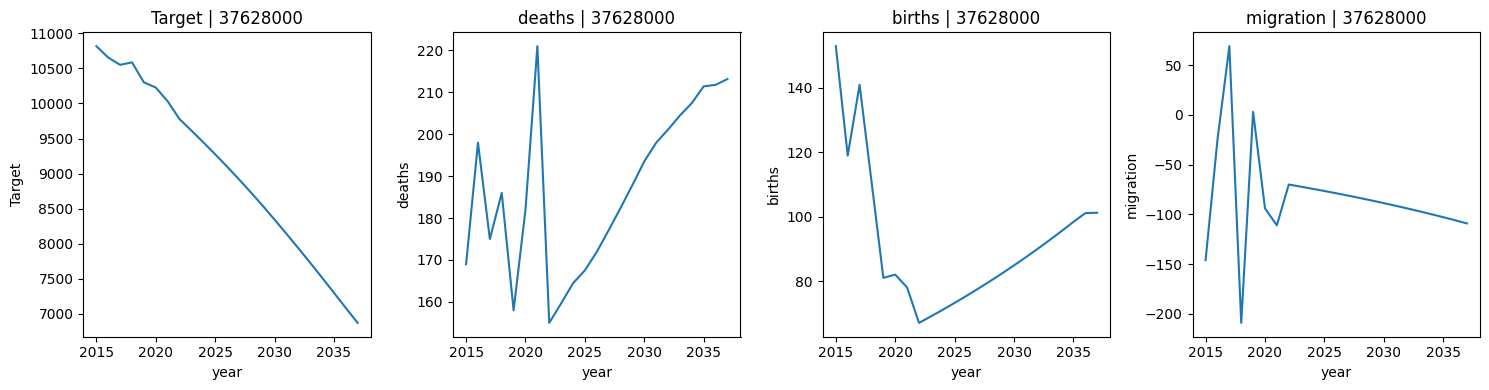

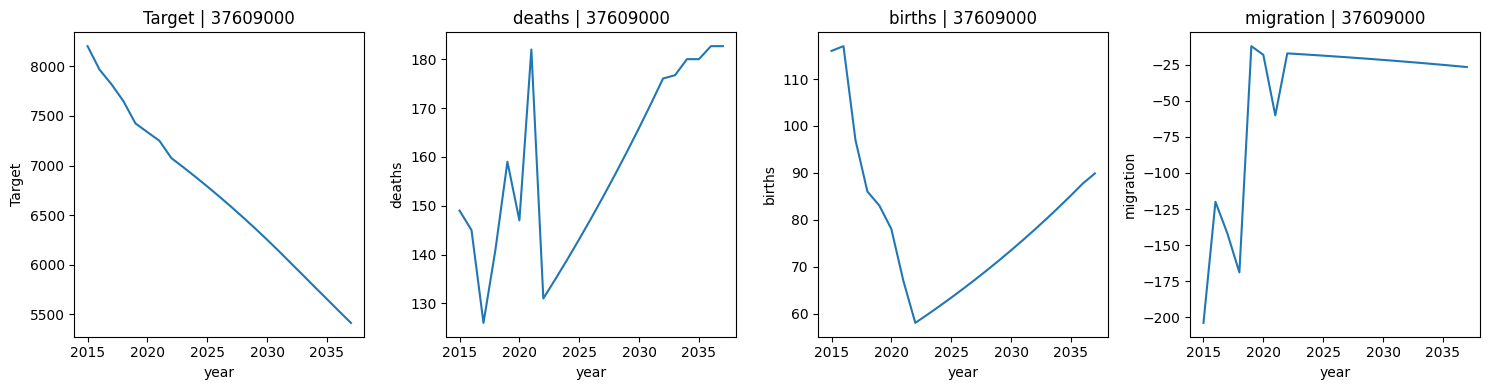

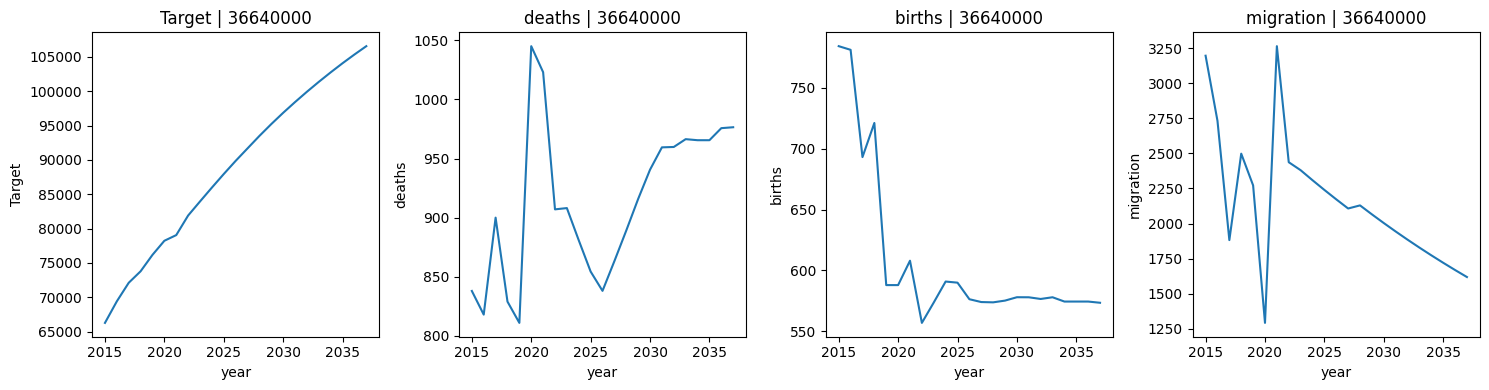

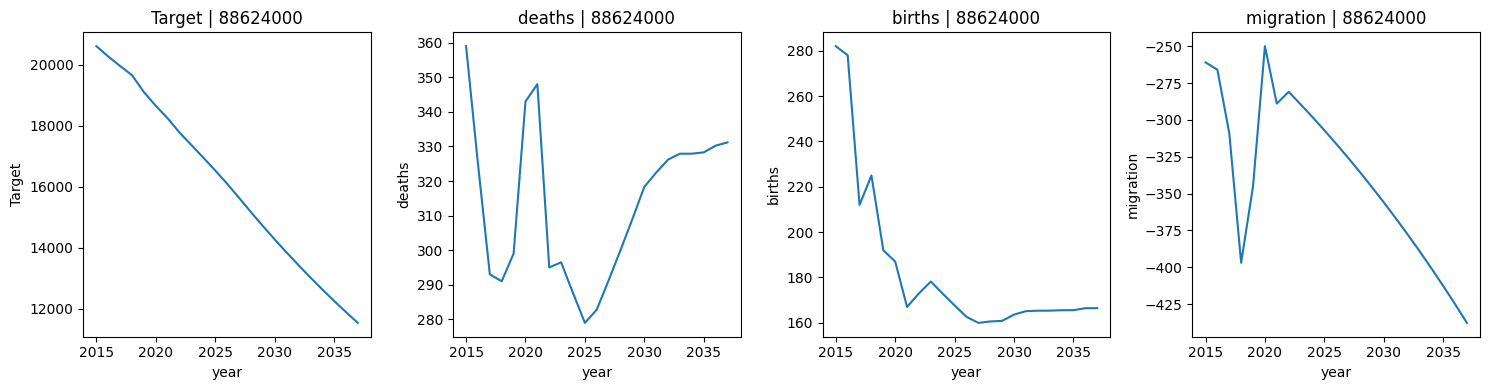

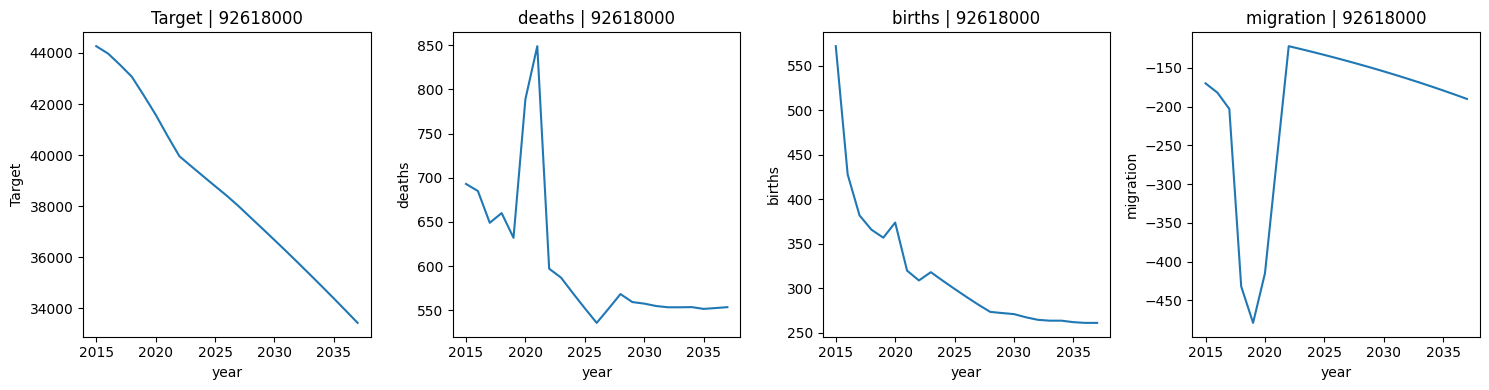

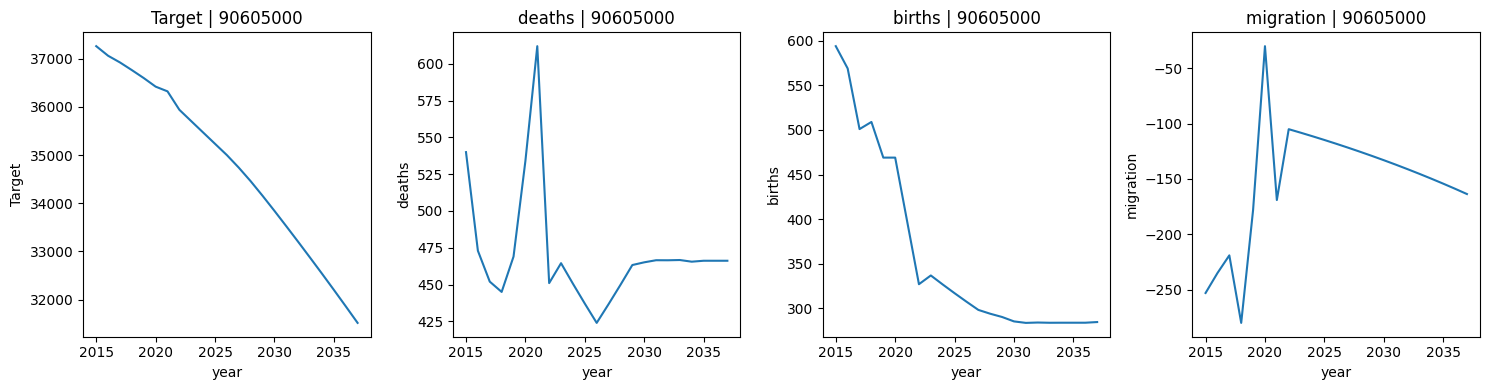

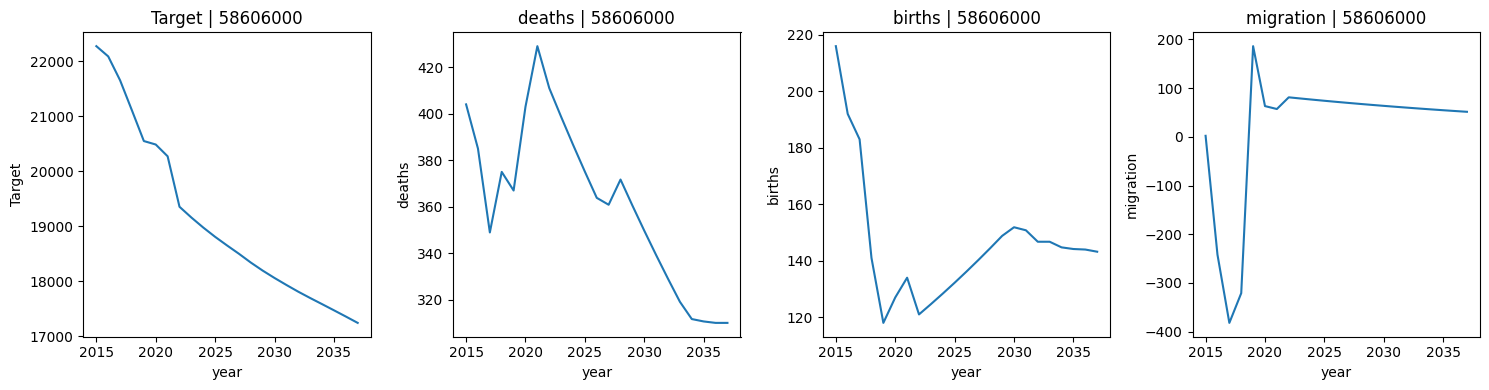

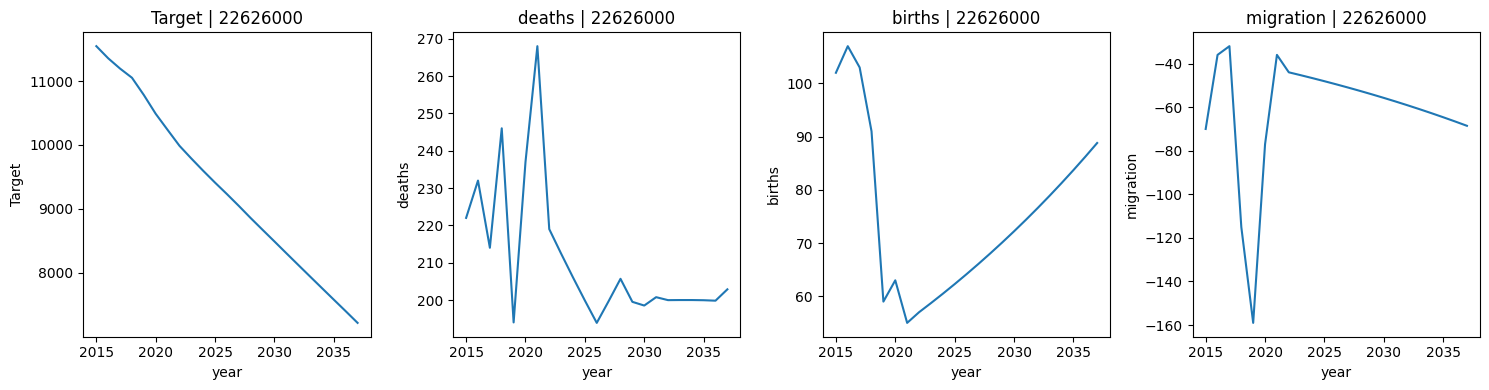

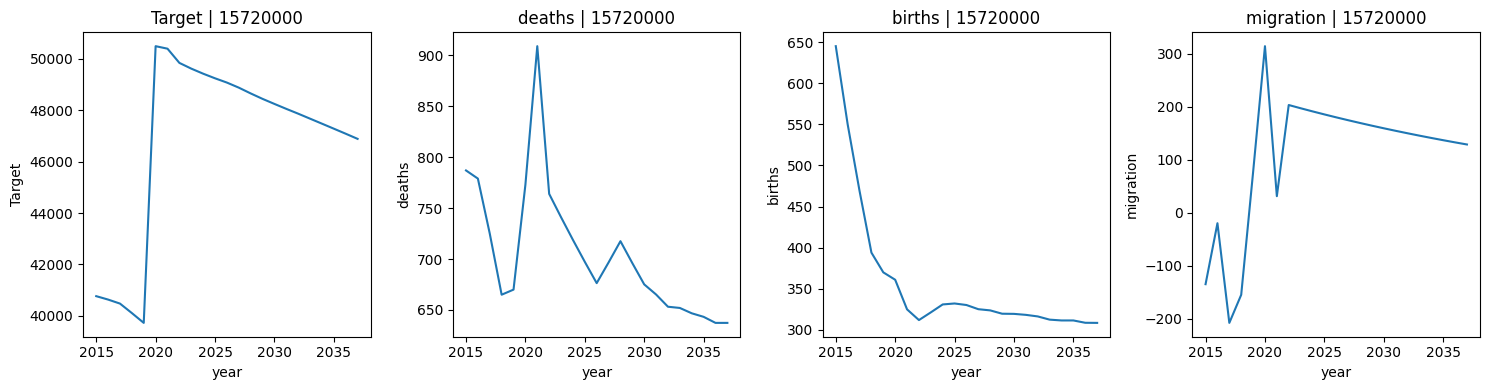

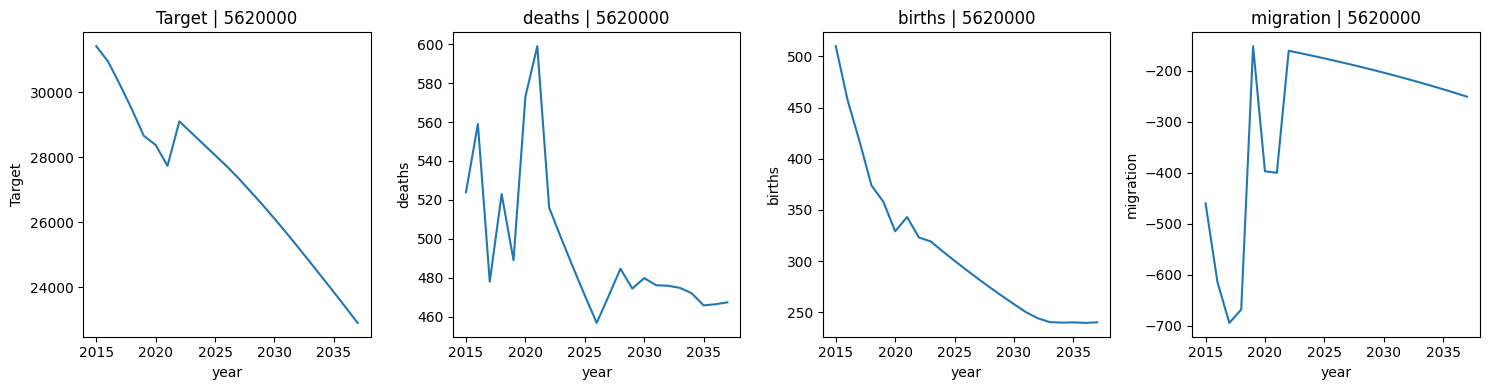

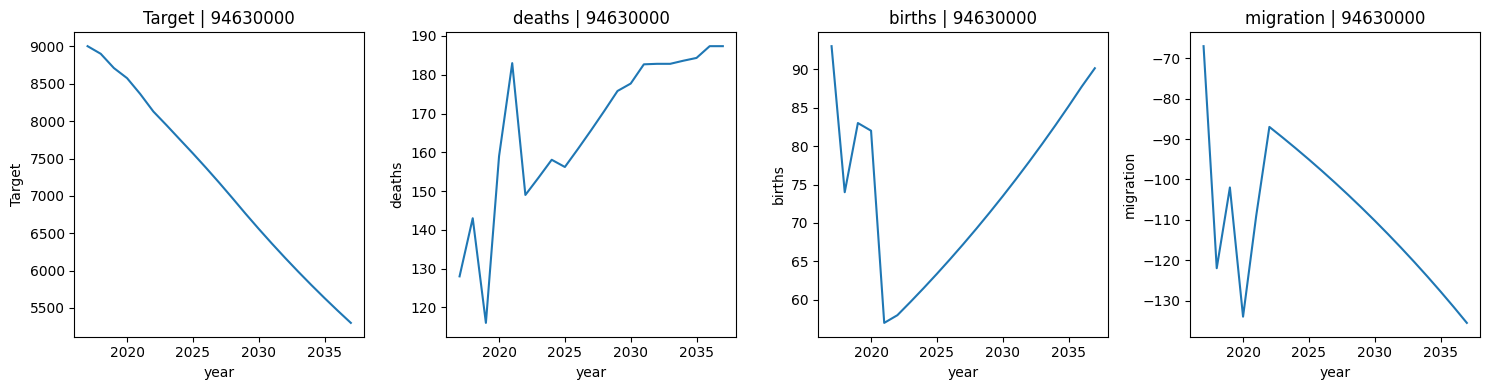

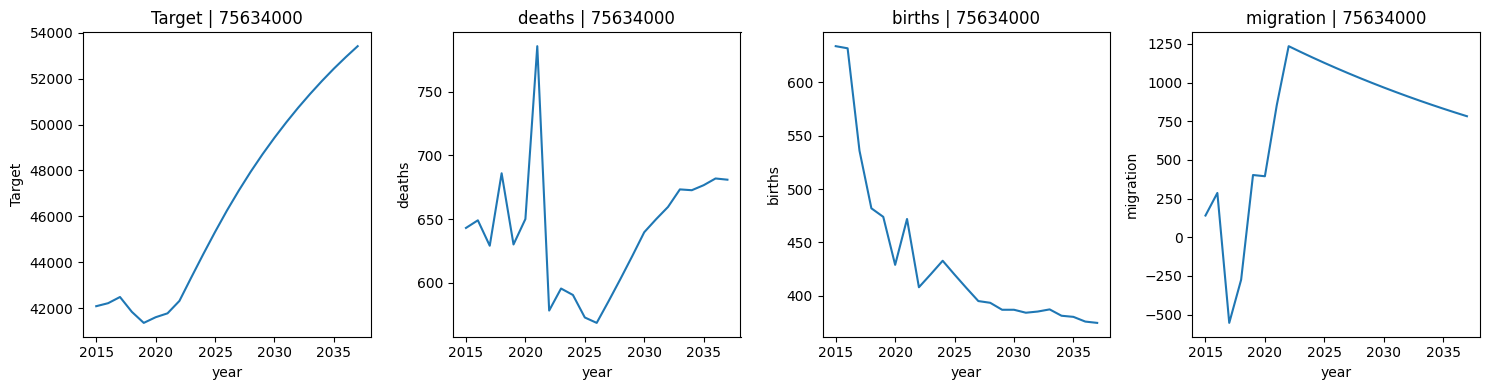

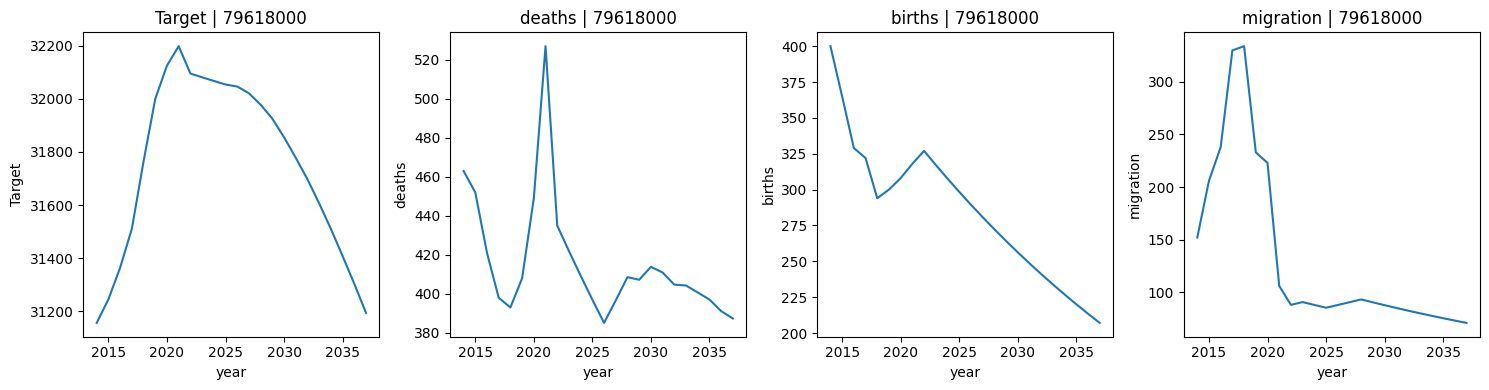

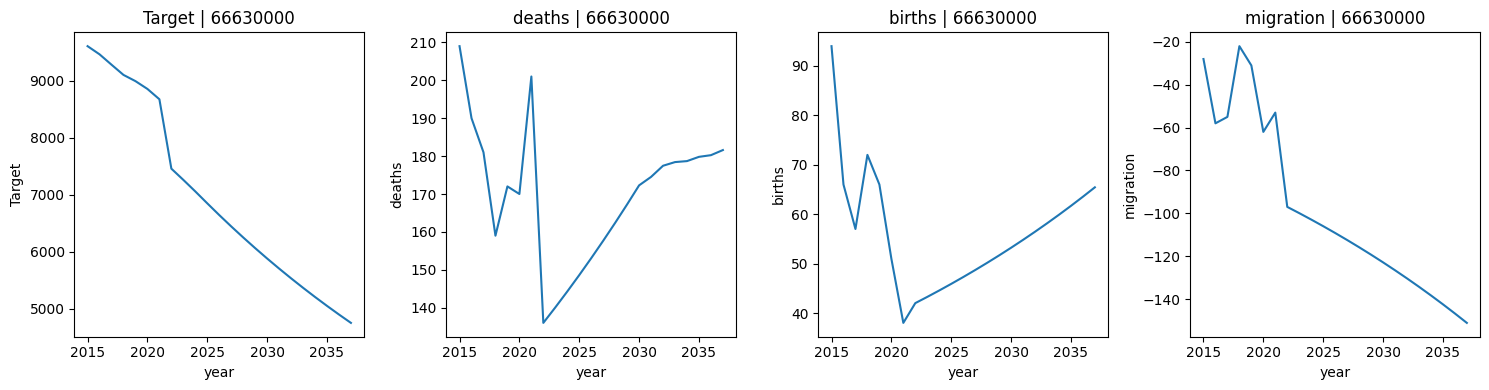

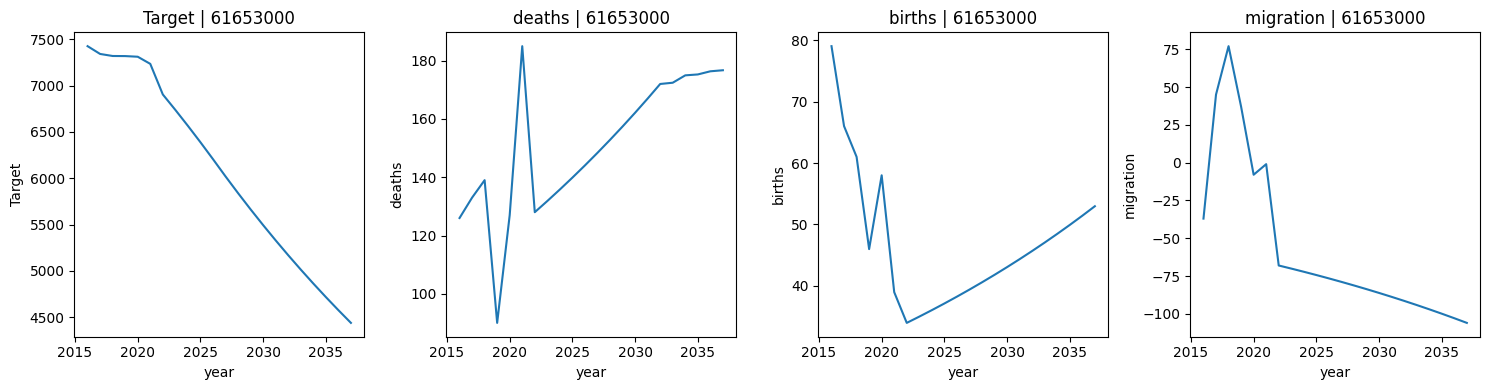

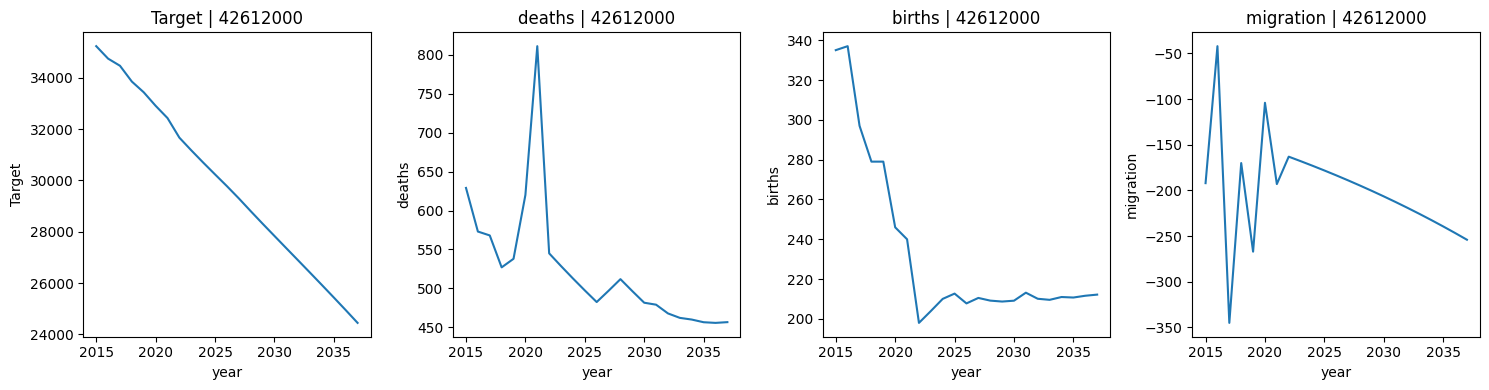

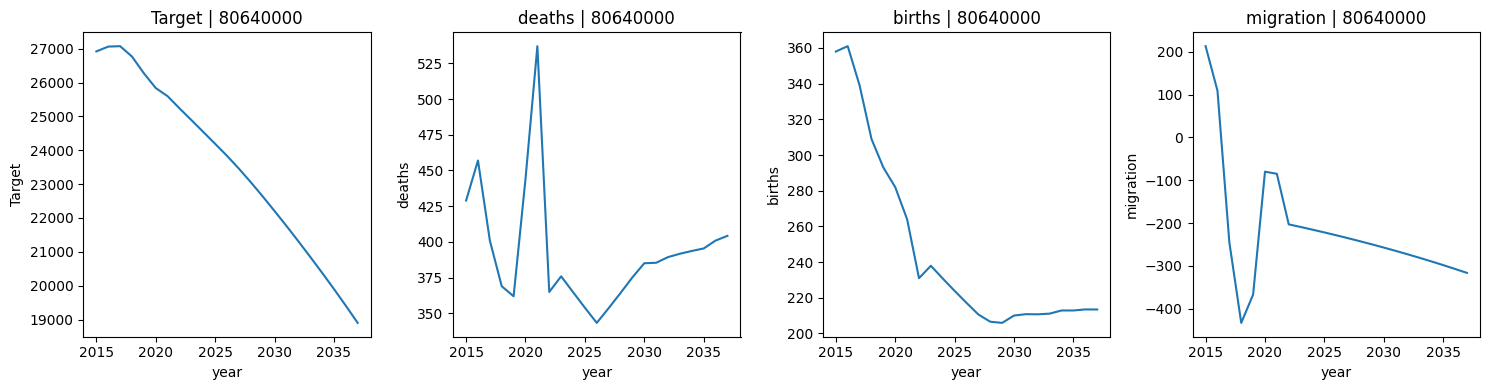

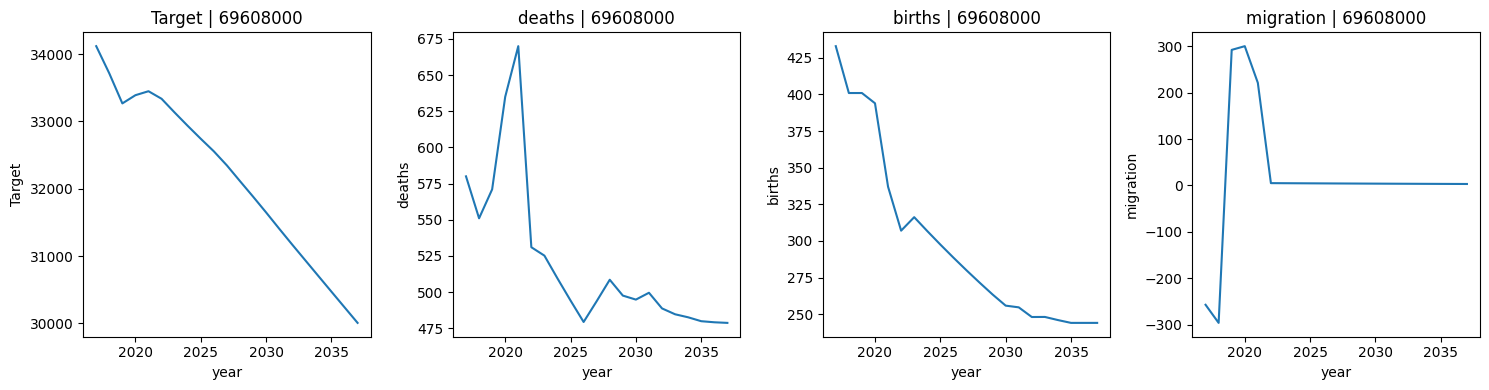

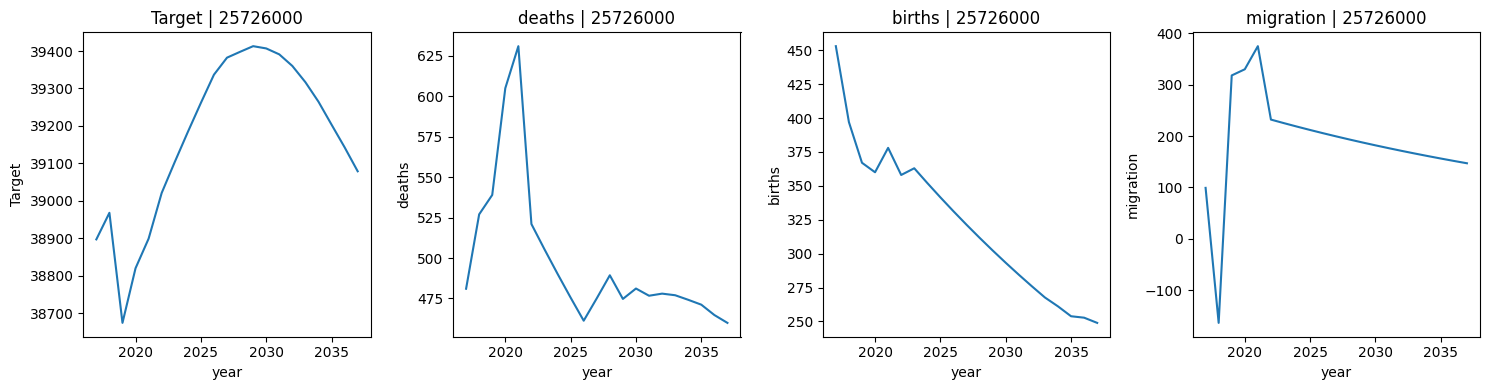

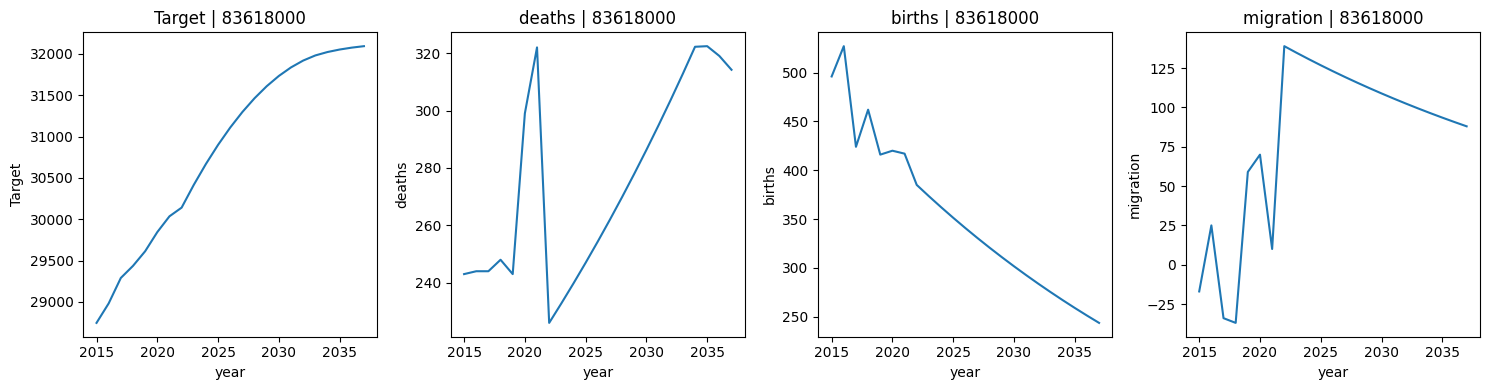

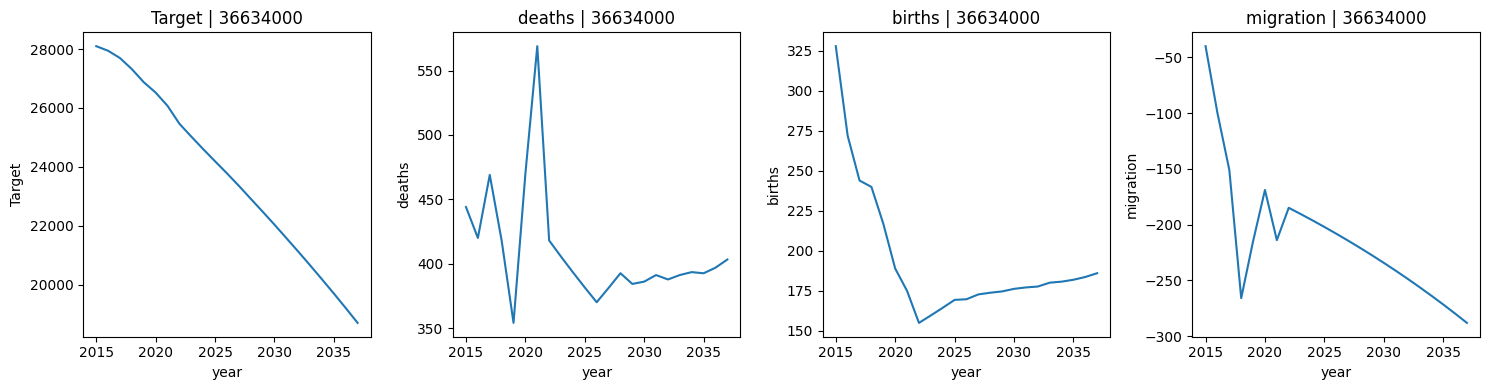

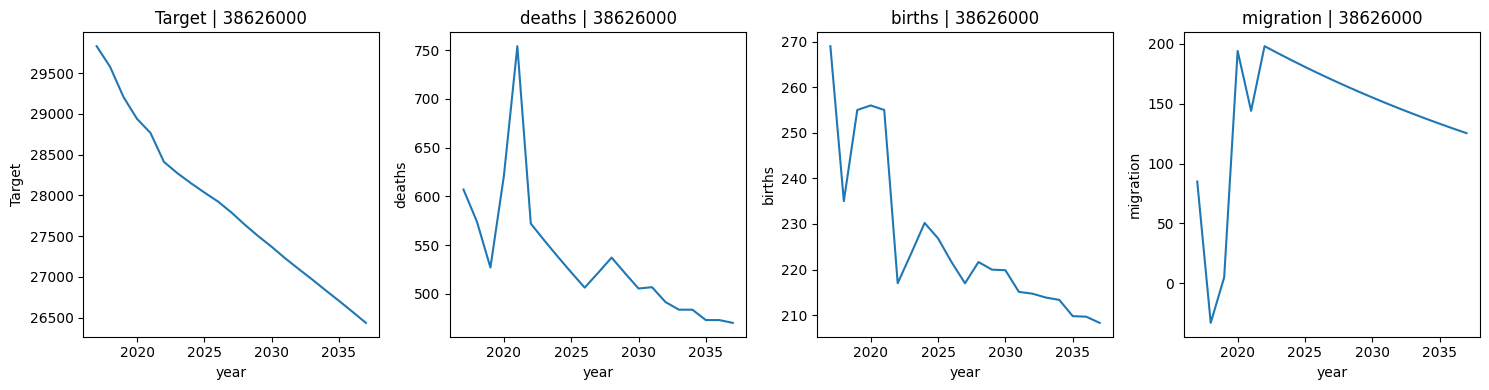

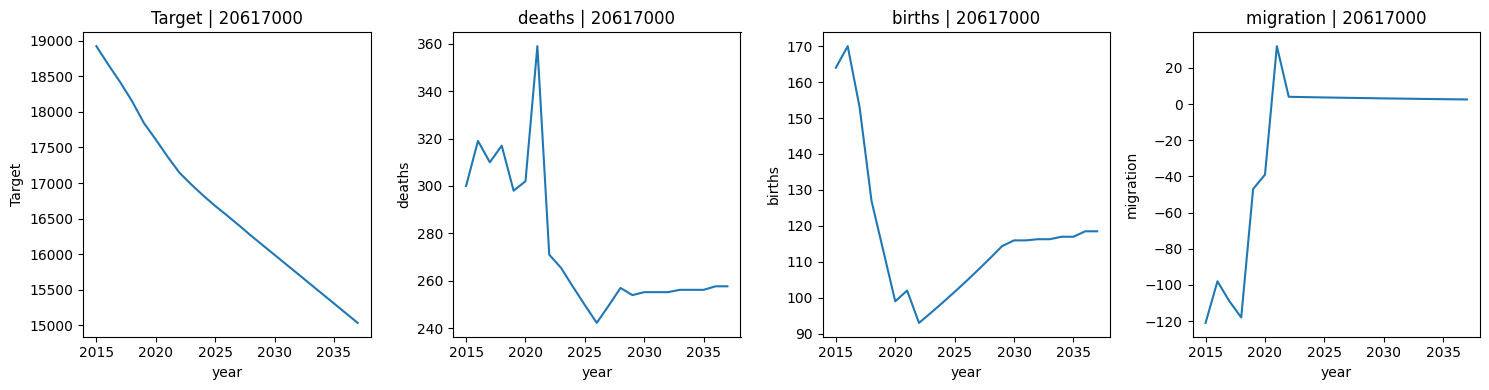

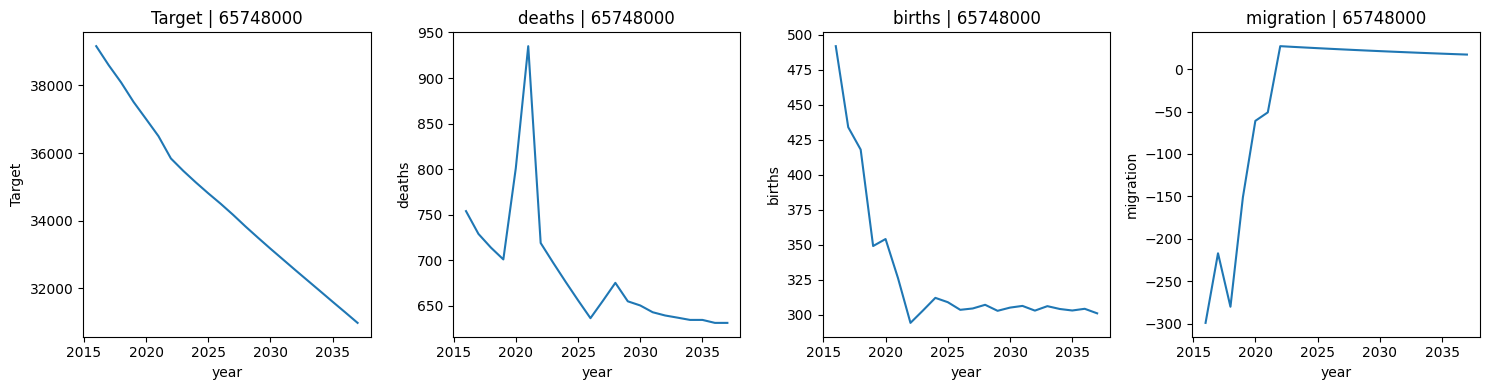

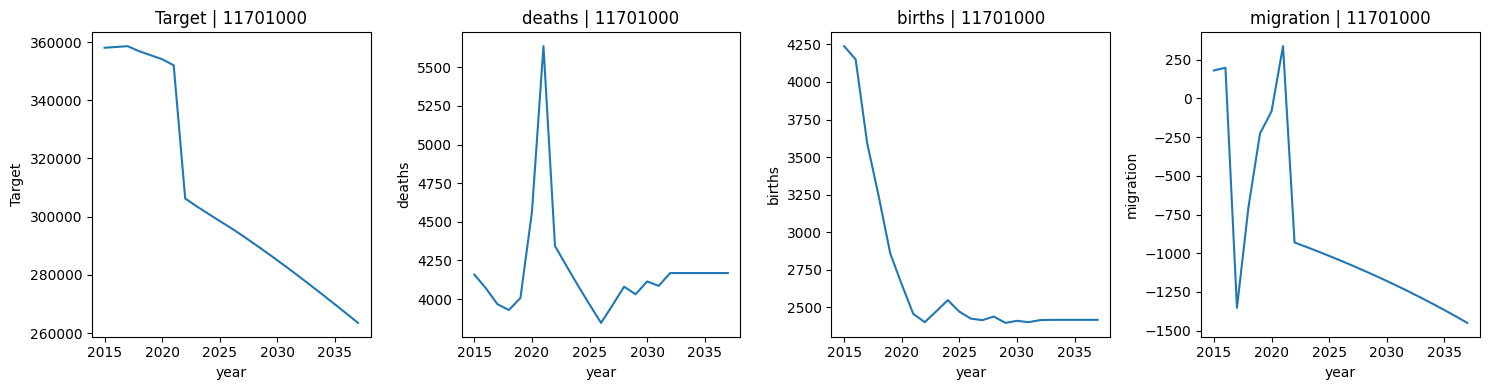

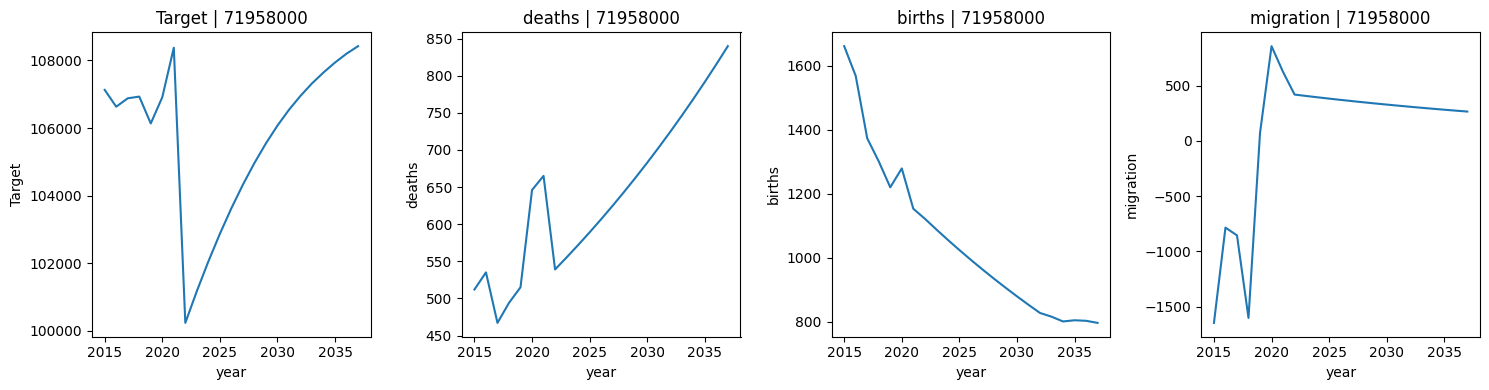

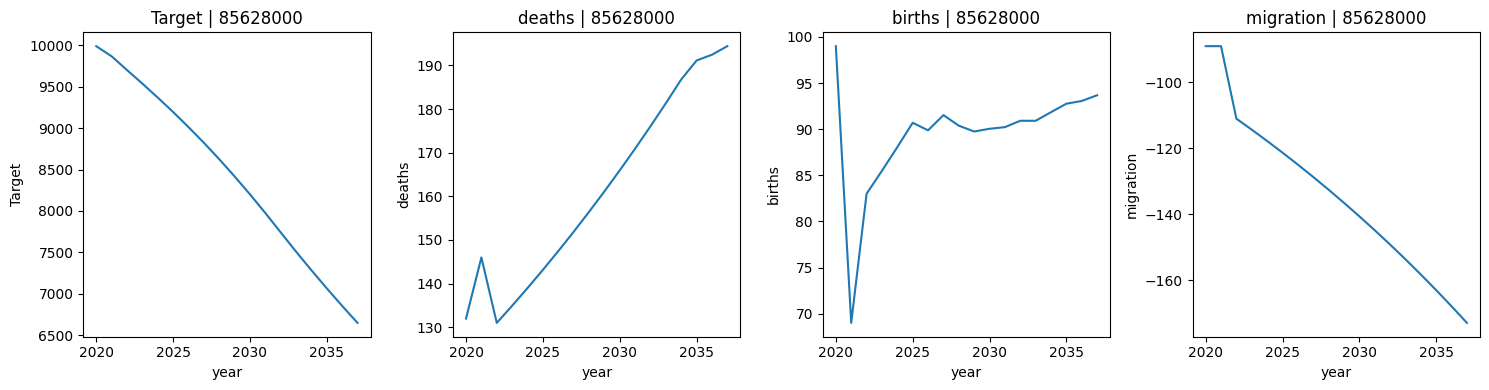

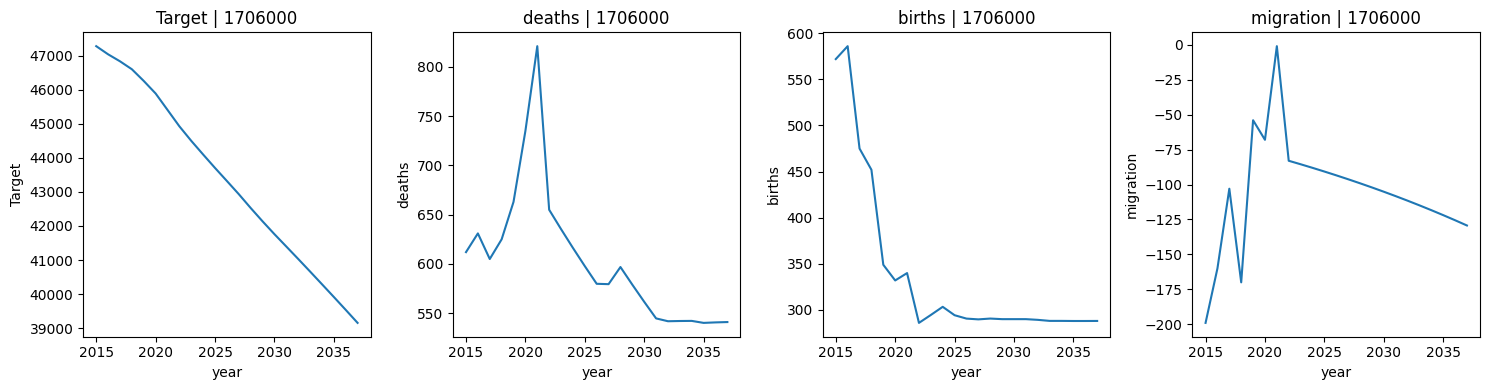

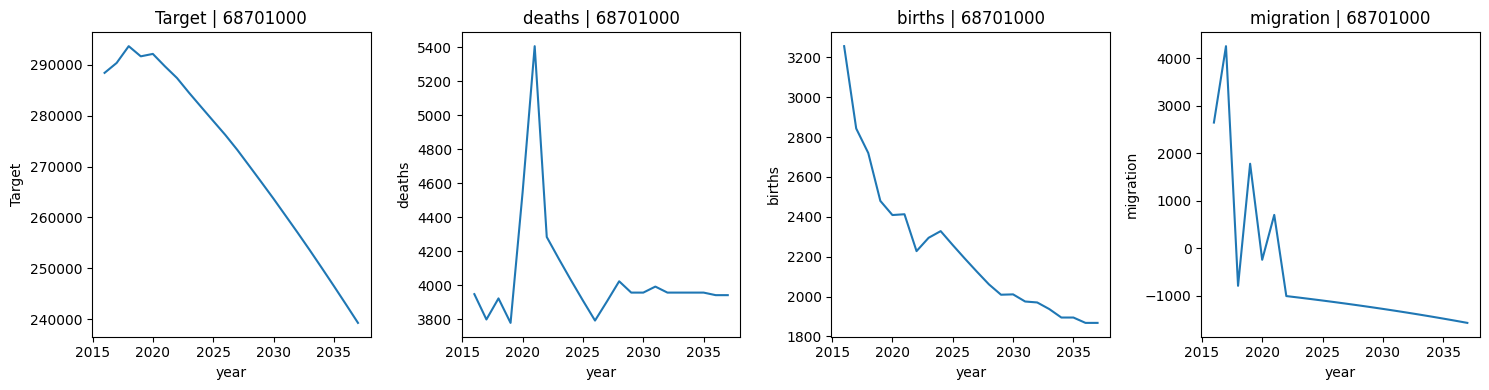

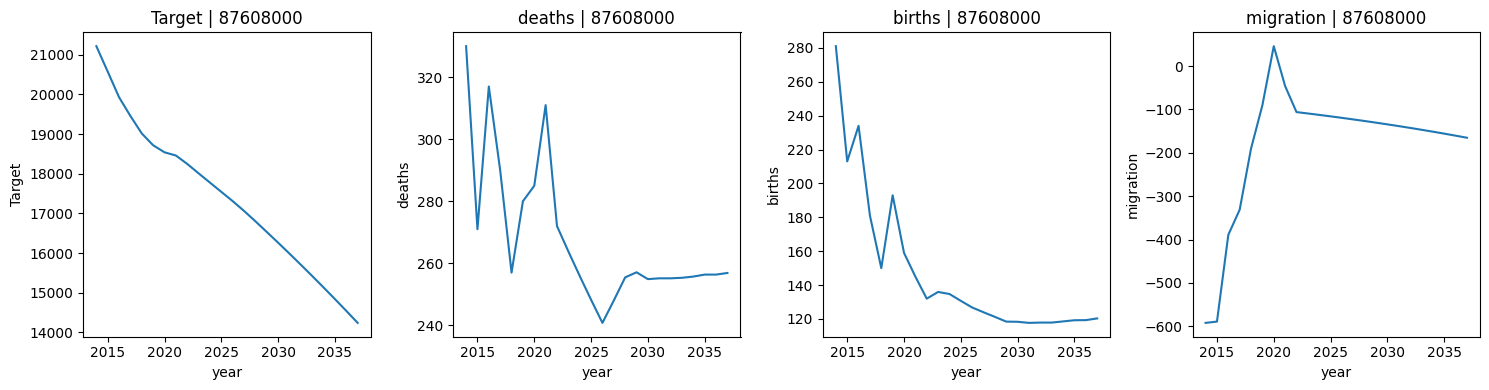

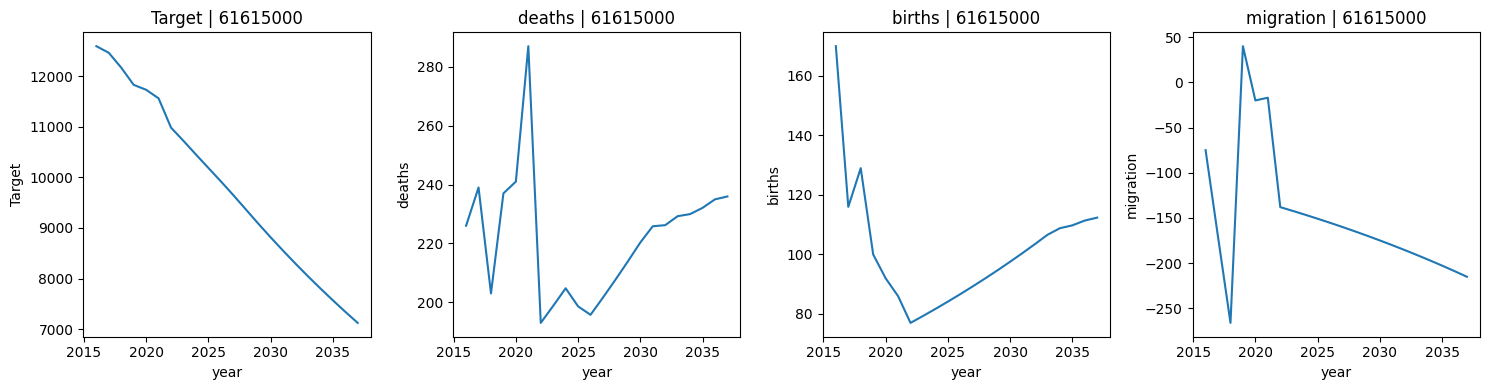

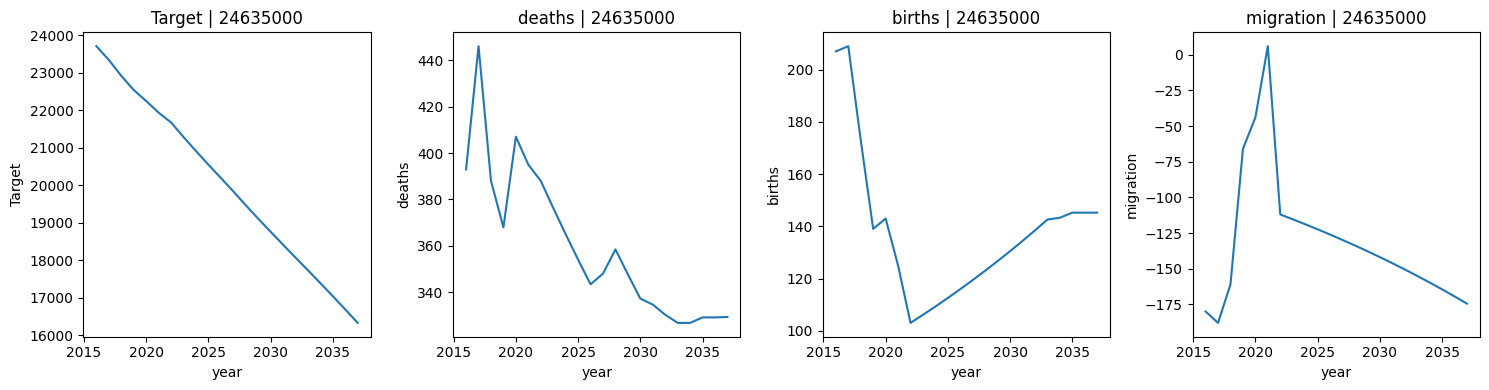

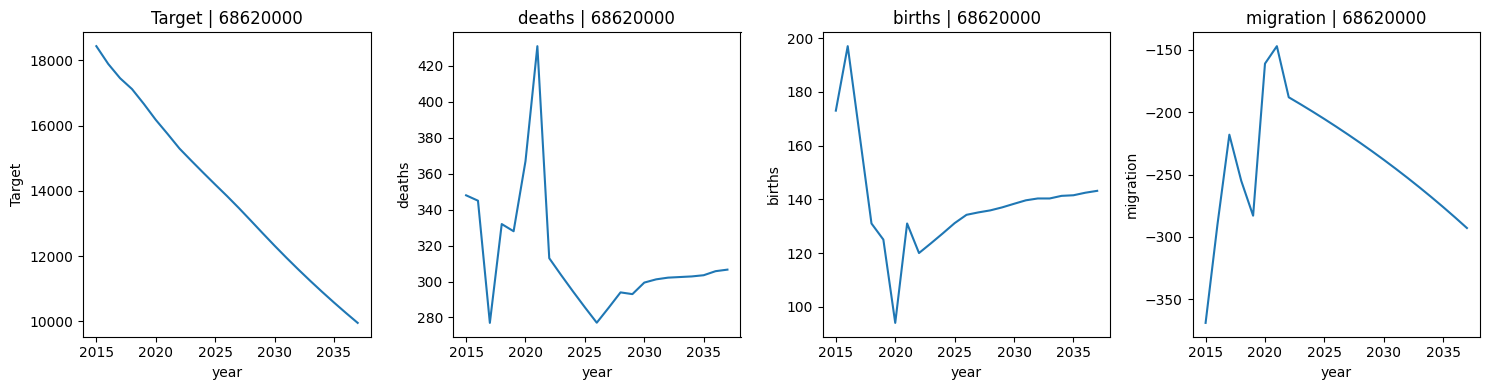

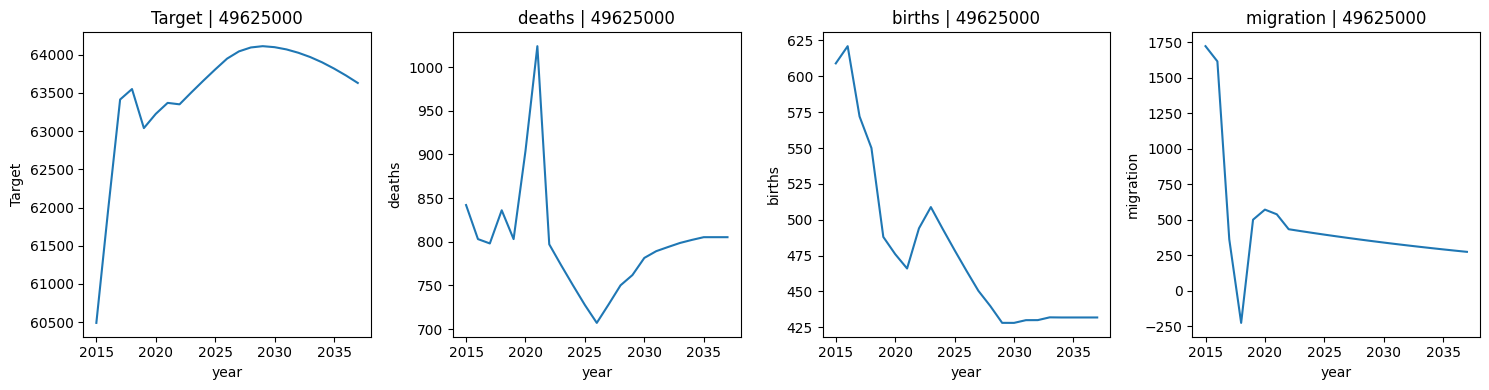

In [ ]:
for i in df2['oktmo'].sample(50).unique():
    fig, ax = plt.subplots(1, 4, figsize=(15 , 4))

    data = df2[df2['oktmo'] == i]

    for j, k in enumerate(ax):
        sns.lineplot(
            data=data,
            x='year',
            y=pred_cols[j],
            ax=k
        )
        k.set_title(f"{pred_cols[j]} | {i}")

    plt.tight_layout()
    plt.show()